# Predicción de la satisfacción de pasajeros mediante Machine Learning

## Pregunta analítica

¿Qué características del pasajero, del viaje y de los servicios permiten predecir su nivel de satisfacción: satisfecho, neutral o insatisfecho?

> Demostración académica basada en datos de satisfacción de pasajeros. No representa decisiones comerciales reales.

In [530]:
# =====================================
# Librerías
# =====================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

In [531]:
# =====================================
# Ruta del dataset
# =====================================

ROOT = Path.cwd().parent

DATA = ROOT / "data"

DATASET = DATA / "satisfaction_2015.xlsx"

print(DATASET)
print(DATASET.exists())

c:\EDA_EVERSON\satisfaccion pasajeros\data\satisfaction_2015.xlsx
True


In [532]:
# =====================================
# Cargar el dataset
# =====================================

df = pd.read_excel(DATASET)

df.head()

,id,satisfaction_v2,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,117135,satisfied,Male,disloyal Customer,56,Personal Travel,Eco,369,0,2,0,4,3,0,3,3,1,5,3,3,4,3,0,0.0
1,72091,satisfied,Male,disloyal Customer,49,Personal Travel,Eco,2486,0,2,1,4,2,1,3,2,1,1,4,4,3,2,0,0.0
2,29663,satisfied,Male,disloyal Customer,55,Personal Travel,Eco,1448,0,3,0,4,3,0,3,3,3,5,3,2,3,3,0,0.0
3,81849,satisfied,Female,disloyal Customer,36,Personal Travel,Eco,1501,0,4,0,3,4,0,4,4,5,4,5,5,5,4,0,0.0
4,83693,satisfied,Male,disloyal Customer,55,Personal Travel,Eco,577,0,5,0,3,3,5,3,3,3,4,5,3,4,3,0,0.0


In [533]:
# =====================================
# Dimensiones del dataset
# =====================================

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas: 129,880
Columnas: 24


In [534]:
# =====================================
# Información general
# =====================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 129880 non-null  int64  
 1   satisfaction_v2                    129880 non-null  str    
 2   Gender                             129880 non-null  str    
 3   Customer Type                      129880 non-null  str    
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  str    
 6   Class                              129880 non-null  str    
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      129880 non-null

In [535]:
# =====================================
# Tipos de datos
# =====================================

df.dtypes

id                                     int64
satisfaction_v2                          str
Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure 

In [536]:
# =====================================
# Estadísticas descriptivas
# =====================================

df.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [537]:
# =====================================
# Estadísticas de variables categóricas
# =====================================

df.describe(include="object")

C:\Users\jhonh\AppData\Local\Temp\ipykernel_15256\3034059920.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,satisfaction_v2,Gender,Customer Type,Type of Travel,Class
count,129880,129880,129880,129880,129880
unique,2,2,2,2,3
top,neutral or dissatisfied,Female,Loyal Customer,Business travel,Business
freq,73452,65899,106100,89693,62160


# Comprensión del dataset

En esta sección se describe el conjunto de datos utilizado para entrenar los modelos de Machine Learning.

In [538]:
# Número de filas y columnas

print(f"Número de registros : {df.shape[0]:,}")
print(f"Número de variables : {df.shape[1]}")

Número de registros : 129,880
Número de variables : 24


In [539]:
# Nombre de las columnas

df.columns

Index(['id', 'satisfaction_v2', 'Gender', 'Customer Type', 'Age',
       'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='str')

In [540]:
# Valores faltantes

df.isnull().sum()

id                                     0
satisfaction_v2                        0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [541]:
# Cantidad total de valores faltantes

df.isnull().sum().sum()

np.int64(393)

In [542]:
# Variables categóricas

df.select_dtypes(include="object").columns

C:\Users\jhonh\AppData\Local\Temp\ipykernel_15256\3635720454.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['satisfaction_v2', 'Gender', 'Customer Type', 'Type of Travel',
       'Class'],
      dtype='str')

In [543]:
# Variables numéricas

df.select_dtypes(exclude="object").columns

Index(['id', 'Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='str')

# Calidad de los datos

En esta sección se verifica la calidad del conjunto de datos mediante la identificación de valores faltantes, registros duplicados y la distribución de la variable objetivo.

In [544]:
# =====================================
# Valores nulos
# =====================================

nulos = df.isnull().sum()

nulos[nulos > 0]

Arrival Delay in Minutes    393
dtype: int64

In [545]:
# =====================================
# Registros duplicados
# =====================================

duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


In [546]:
# =====================================
# Variable objetivo
# =====================================

df["satisfaction_v2"].value_counts()

satisfaction_v2
neutral or dissatisfied    73452
satisfied                  56428
Name: count, dtype: int64

In [547]:
# ==========================================
# CREACIÓN DE LAS TRES CATEGORÍAS
# ==========================================

# Columnas que evalúan los servicios de la aerolínea
columnas_servicio = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

# El valor 0 significa que el servicio no fue evaluado
calificaciones_servicio = (
    df[columnas_servicio]
    .replace(0, float("nan"))
)

# Calcular el promedio de servicios de cada pasajero
df["promedio_servicio"] = calificaciones_servicio.mean(axis=1)

# Crear las tres categorías
def clasificar_satisfaccion(fila):

    # Mantener a los pasajeros originalmente satisfechos
    if fila["satisfaction_v2"] == "satisfied":
        return "Satisfecho"

    # Separar el grupo neutral o insatisfecho
    if fila["promedio_servicio"] > 3:
        return "Neutral"

    return "Insatisfecho"

# Aplicar la clasificación
df["nivel_satisfaccion"] = df.apply(
    clasificar_satisfaccion,
    axis=1
)

# Mostrar la cantidad de pasajeros por categoría
df["nivel_satisfaccion"].value_counts()

nivel_satisfaccion
Satisfecho      56428
Insatisfecho    39535
Neutral         33917
Name: count, dtype: int64

In [548]:
# Porcentaje de cada nivel de satisfacción
porcentajes_satisfaccion = (
    df["nivel_satisfaccion"]
    .value_counts(normalize=True)
    .reindex(["Satisfecho", "Neutral", "Insatisfecho"])
    * 100
)

porcentajes_satisfaccion.round(2)

nivel_satisfaccion
Satisfecho      43.45
Neutral         26.11
Insatisfecho    30.44
Name: proportion, dtype: float64

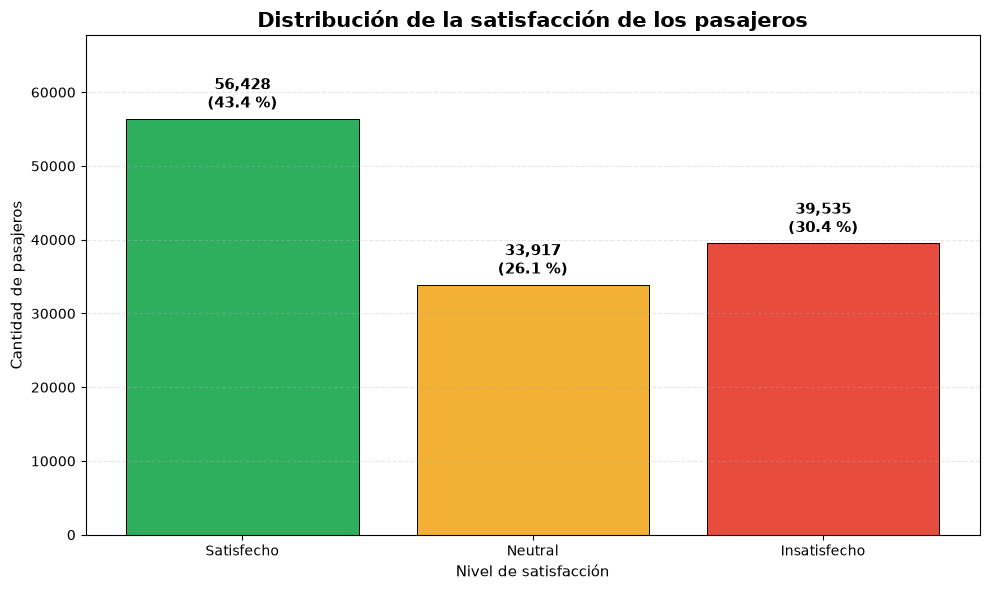

In [549]:
# Orden de las categorías
orden = ["Satisfecho", "Neutral", "Insatisfecho"]

# Calcular las cantidades
distribucion = (
    df["nivel_satisfaccion"]
    .value_counts()
    .reindex(orden, fill_value=0)
)

# Colores: verde, amarillo y rojo
colores = ["#2EAF5D", "#F2B134", "#E74C3C"]

plt.figure(figsize=(10, 6))

barras = plt.bar(
    distribucion.index,
    distribucion.values,
    color=colores,
    edgecolor="black",
    linewidth=0.7
)

# Agregar cantidad y porcentaje sobre cada barra
total = distribucion.sum()

for barra, cantidad in zip(barras, distribucion.values):
    porcentaje = cantidad / total * 100

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 800,
        f"{cantidad:,}\n({porcentaje:.1f} %)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Distribución de la satisfacción de los pasajeros",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Nivel de satisfacción", fontsize=11)
plt.ylabel("Cantidad de pasajeros", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.ylim(0, distribucion.max() * 1.20)
plt.tight_layout()
plt.show()

# 4 Análisis Exploratorio de Datos (EDA)

En esta sección se explora la relación entre las características de los pasajeros y sus niveles de satisfacción. Se analizan variables categóricas, valoraciones de los servicios y variables numéricas.

In [550]:
# ==========================================
# EDA de variables categóricas
# ==========================================

variables_categoricas_eda = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

resultados_categoricos = []

for variable in variables_categoricas_eda:

    tabla = (
        df.groupby(
            [variable, "nivel_satisfaccion"]
        )
        .size()
        .reset_index(name="cantidad")
    )

    tabla = tabla.rename(
        columns={variable: "categoria"}
    )

    tabla["variable"] = variable

    resultados_categoricos.append(tabla)

eda_categoricas = pd.concat(
    resultados_categoricos,
    ignore_index=True
)

eda_categoricas = eda_categoricas[
    [
        "variable",
        "categoria",
        "nivel_satisfaccion",
        "cantidad"
    ]
]

eda_categoricas.to_csv(
    "../data/eda_categoricas.csv",
    index=False
)

eda_categoricas.head()

,variable,categoria,nivel_satisfaccion,cantidad
0,Gender,Female,Insatisfecho,20257
1,Gender,Female,Neutral,17373
2,Gender,Female,Satisfecho,28269
3,Gender,Male,Insatisfecho,19278
4,Gender,Male,Neutral,16544


In [551]:
# ==========================================
# EDA de valoraciones de los servicios
# ==========================================

eda_servicios = (
    df.groupby("nivel_satisfaccion")[columnas_servicio]
    .mean()
    .round(2)
    .reset_index()
    .melt(
        id_vars="nivel_satisfaccion",
        var_name="servicio",
        value_name="promedio"
    )
)

eda_servicios.to_csv(
    "../data/eda_servicios.csv",
    index=False
)

eda_servicios.head()

,nivel_satisfaccion,servicio,promedio
0,Insatisfecho,Inflight wifi service,2.09
1,Neutral,Inflight wifi service,2.76
2,Satisfecho,Inflight wifi service,3.16
3,Insatisfecho,Departure/Arrival time convenient,2.71
4,Neutral,Departure/Arrival time convenient,3.62


In [552]:
# ==========================================
# EDA de variables numéricas
# ==========================================

variables_numericas_eda = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

resultados_numericos = []

for variable in variables_numericas_eda:

    tabla = (
        df.groupby("nivel_satisfaccion")[variable]
        .agg(
            promedio="mean",
            mediana="median",
            minimo="min",
            maximo="max"
        )
        .round(2)
        .reset_index()
    )

    tabla["variable"] = variable

    resultados_numericos.append(tabla)

eda_numericas = pd.concat(
    resultados_numericos,
    ignore_index=True
)

eda_numericas = eda_numericas[
    [
        "variable",
        "nivel_satisfaccion",
        "promedio",
        "mediana",
        "minimo",
        "maximo"
    ]
]

eda_numericas.to_csv(
    "../data/eda_numericas.csv",
    index=False
)

eda_numericas.head()

,variable,nivel_satisfaccion,promedio,mediana,minimo,maximo
0,Age,Insatisfecho,37.90,37.0,7.0,85.0
1,Age,Neutral,37.36,36.0,7.0,85.0
2,Age,Satisfecho,41.74,43.0,7.0,85.0
3,Flight Distance,Insatisfecho,988.69,693.0,31.0,4983.0
4,Flight Distance,Neutral,860.97,645.0,31.0,4983.0


# 5 Preparación de los datos

En esta sección se prepara el conjunto de datos para el entrenamiento de los modelos de Machine Learning mediante la eliminación de variables innecesarias, codificación de variables categóricas y división del conjunto de entrenamiento y prueba.

In [553]:
# ==========================================
# Importar librerías para Machine Learning
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [554]:
# ==========================================
# Crear una copia del dataset original
# ==========================================
# Se trabaja sobre una copia para evitar
# modificar el conjunto de datos original.
# ==========================================

modelo = df.copy()

modelo.head()

,id,satisfaction_v2,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,promedio_servicio,nivel_satisfaccion
0,117135,satisfied,Male,disloyal Customer,56,Personal Travel,Eco,369,0,2,0,4,3,0,3,3,1,5,3,3,4,3,0,0.0,3.090909,Satisfecho
1,72091,satisfied,Male,disloyal Customer,49,Personal Travel,Eco,2486,0,2,1,4,2,1,3,2,1,1,4,4,3,2,0,0.0,2.307692,Satisfecho
2,29663,satisfied,Male,disloyal Customer,55,Personal Travel,Eco,1448,0,3,0,4,3,0,3,3,3,5,3,2,3,3,0,0.0,3.181818,Satisfecho
3,81849,satisfied,Female,disloyal Customer,36,Personal Travel,Eco,1501,0,4,0,3,4,0,4,4,5,4,5,5,5,4,0,0.0,4.272727,Satisfecho
4,83693,satisfied,Male,disloyal Customer,55,Personal Travel,Eco,577,0,5,0,3,3,5,3,3,3,4,5,3,4,3,0,0.0,3.666667,Satisfecho


In [555]:
# ==========================================
# Eliminar columnas que no deben utilizarse
# como variables predictoras
# ==========================================
#
# id: solamente identifica al pasajero.
#
# satisfaction_v2: contiene la clasificación
# original de dos categorías.
#
# promedio_servicio: se utilizó para crear
# las tres categorías.
# ==========================================

modelo = modelo.drop(
    columns=[
        "id",
        "satisfaction_v2",
        "promedio_servicio"
    ]
)

modelo.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,nivel_satisfaccion
0,Male,disloyal Customer,56,Personal Travel,Eco,369,0,2,0,4,3,0,3,3,1,5,3,3,4,3,0,0.0,Satisfecho
1,Male,disloyal Customer,49,Personal Travel,Eco,2486,0,2,1,4,2,1,3,2,1,1,4,4,3,2,0,0.0,Satisfecho
2,Male,disloyal Customer,55,Personal Travel,Eco,1448,0,3,0,4,3,0,3,3,3,5,3,2,3,3,0,0.0,Satisfecho
3,Female,disloyal Customer,36,Personal Travel,Eco,1501,0,4,0,3,4,0,4,4,5,4,5,5,5,4,0,0.0,Satisfecho
4,Male,disloyal Customer,55,Personal Travel,Eco,577,0,5,0,3,3,5,3,3,3,4,5,3,4,3,0,0.0,Satisfecho


In [556]:
# ==========================================
# Verificar los tipos de datos
# ==========================================
# Antes de entrenar los modelos es importante
# conocer qué variables son numéricas y cuáles
# son categóricas.
# ==========================================

modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  str    
 1   Customer Type                      129880 non-null  str    
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  str    
 4   Class                              129880 non-null  str    
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    129880 non-null

In [557]:
# ==========================================
# Transformar variables categóricas
# ==========================================
# Los algoritmos de Machine Learning solo
# trabajan con valores numéricos, por ello
# las variables de tipo texto se convierten
# en números mediante LabelEncoder.
# ==========================================

label_encoders = {}

for columna in modelo.select_dtypes(include="object").columns:

    encoder = LabelEncoder()

    modelo[columna] = encoder.fit_transform(modelo[columna])

    label_encoders[columna] = encoder

modelo.head()

C:\Users\jhonh\AppData\Local\Temp\ipykernel_15256\577092754.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for columna in modelo.select_dtypes(include="object").columns:


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,nivel_satisfaccion
0,1,1,56,1,1,369,0,2,0,4,3,0,3,3,1,5,3,3,4,3,0,0.0,2
1,1,1,49,1,1,2486,0,2,1,4,2,1,3,2,1,1,4,4,3,2,0,0.0,2
2,1,1,55,1,1,1448,0,3,0,4,3,0,3,3,3,5,3,2,3,3,0,0.0,2
3,0,1,36,1,1,1501,0,4,0,3,4,0,4,4,5,4,5,5,5,4,0,0.0,2
4,1,1,55,1,1,577,0,5,0,3,3,5,3,3,3,4,5,3,4,3,0,0.0,2


In [558]:
# ==========================================
# Tratamiento de valores nulos
# ==========================================
# La variable "Arrival Delay in Minutes"
# presenta 393 valores faltantes.
#
# Estos valores se reemplazan utilizando
# la mediana para conservar la distribución
# de la variable.
# ==========================================

modelo["Arrival Delay in Minutes"] = (
    modelo["Arrival Delay in Minutes"]
    .fillna(modelo["Arrival Delay in Minutes"].median())
)

In [559]:
# ==========================================
# Verificar que no existan valores nulos
# ==========================================

modelo.isnull().sum().sort_values(ascending=False)

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
nivel_satisfaccion                   0
dtype: int64

In [560]:
# ==========================================
# Comprobar que todas las variables sean
# numéricas después de la preparación
# ==========================================

modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  int64  
 1   Customer Type                      129880 non-null  int64  
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  int64  
 4   Class                              129880 non-null  int64  
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    129880 non-null

In [561]:
# ==========================================
# Separar variables predictoras (X)
# y variable objetivo (y)
# ==========================================
# X contiene todas las variables que utilizará
# el modelo para realizar la predicción.
#
# y corresponde al nivel de satisfacción
# del pasajero.
# ==========================================

X = modelo.drop(columns=["nivel_satisfaccion"])

y = modelo["nivel_satisfaccion"]

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

print("\nDistribución de las categorías:")
print(y.value_counts().sort_index())

Variables predictoras: (129880, 22)
Variable objetivo: (129880,)

Distribución de las categorías:
nivel_satisfaccion
0    39535
1    33917
2    56428
Name: count, dtype: int64


In [562]:
# ==========================================
# Verificar el tamaño de X e y
# ==========================================

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (129880, 22)
Variable objetivo: (129880,)


In [563]:
# ==========================================
# Dividir el dataset
# ==========================================
# 80% de los datos se utilizarán para
# entrenar los modelos.
#
# 20% de los datos se reservarán para
# evaluar el desempeño del modelo.
#
# random_state = 42 garantiza que los
# resultados puedan reproducirse.
#
# stratify = y mantiene la misma proporción
# de pasajeros satisfechos e insatisfechos
# en ambos conjuntos.
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [564]:
# ==========================================
# Verificar la cantidad de registros
# para entrenamiento y prueba
# ==========================================

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (103904, 22)
Prueba: (25976, 22)


# 6 Entrenamiento de modelos de Machine Learning

En esta sección se entrenan tres algoritmos de clasificación con el objetivo de predecir la satisfacción de los pasajeros. Posteriormente, se comparará el desempeño de cada modelo utilizando diferentes métricas de evaluación.

In [565]:
# ==========================================
# Importar algoritmos de Machine Learning
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# Importar métricas de evaluación
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [566]:
# ==========================================
# Crear los modelos de Machine Learning
# ==========================================

modelo_logistico = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo_arbol = DecisionTreeClassifier(
    random_state=42
)

modelo_bosque = RandomForestClassifier(
    random_state=42
)

In [567]:
# ==========================================
# Entrenar los modelos utilizando
# los datos de entrenamiento
# ==========================================

modelo_logistico.fit(X_train, y_train)

modelo_arbol.fit(X_train, y_train)

modelo_bosque.fit(X_train, y_train)

c:\Users\jhonh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [568]:
# ==========================================
# Confirmar el entrenamiento
# ==========================================

print("Regresión Logística entrenada")
print("Árbol de Decisión entrenado")
print("Random Forest entrenado")

Regresión Logística entrenada
Árbol de Decisión entrenado
Random Forest entrenado


# 7 Evaluación y comparación de modelos

En esta sección se evalúa el desempeño de los modelos de Machine Learning utilizando diferentes métricas de clasificación. Posteriormente, los resultados serán exportados para su visualización en ObservableHQ.

In [569]:
# ==========================================
# Importar librerías para evaluación
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [570]:
# ==========================================
# Función para evaluar modelos multiclase
# ==========================================
# Las métricas utilizan promedio ponderado
# porque ahora existen tres categorías:
# Insatisfecho, Neutral y Satisfecho.
# ==========================================

def evaluar_modelo(nombre, modelo):

    # Obtener predicciones
    y_pred = modelo.predict(X_test)

    # Probabilidad de las tres categorías
    y_prob = modelo.predict_proba(X_test)

    return {
        "modelo": nombre,

        "accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "precision": precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "recall": recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "f1": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )
    }

In [571]:
# ==========================================
# Evaluar los modelos entrenados
# ==========================================

metricas = [

    evaluar_modelo(
        "Regresión Logística",
        modelo_logistico
    ),

    evaluar_modelo(
        "Árbol de Decisión",
        modelo_arbol
    ),

    evaluar_modelo(
        "Random Forest",
        modelo_bosque
    )

]

In [572]:
# ==========================================
# Crear tabla de métricas
# ==========================================

metricas_df = pd.DataFrame(metricas)

metricas_df

,modelo,accuracy,precision,recall,f1,roc_auc
0,Regresión Logística,0.724399,0.720279,0.724399,0.720671,0.882864
1,Árbol de Decisión,0.888281,0.887740,0.888281,0.887969,0.916173
2,Random Forest,0.931591,0.931870,0.931591,0.931598,0.991344


In [573]:
# ==========================================
# Guardar métricas para ObservableHQ
# ==========================================

metricas_df.to_csv(
    "../data/metricas_modelos.csv",
    index=False
)

print("Archivo guardado correctamente.")

Archivo guardado correctamente.


# 8 Matriz de confusión

La matriz de confusión permite analizar el número de predicciones correctas e incorrectas realizadas por el mejor modelo obtenido durante el entrenamiento.

In [574]:
# ==========================================
# Importar librerías
# ==========================================

from sklearn.metrics import confusion_matrix

In [575]:
# ==========================================
# Obtener las predicciones del mejor modelo
# ==========================================

y_pred_rf = modelo_bosque.predict(X_test)

In [576]:
# ==========================================
# Calcular matriz de confusión multiclase
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=[0, 1, 2]
)

cm

array([[ 7529,   311,    67],
       [  417,  6013,   353],
       [  245,   384, 10657]])

In [577]:
# ==========================================
# Crear matriz de confusión de 3 x 3
# ==========================================

matriz_df = pd.DataFrame(
    cm,
    index=[
        "Real Insatisfecho",
        "Real Neutral",
        "Real Satisfecho"
    ],
    columns=[
        "Predicho Insatisfecho",
        "Predicho Neutral",
        "Predicho Satisfecho"
    ]
)

matriz_df

,Predicho Insatisfecho,Predicho Neutral,Predicho Satisfecho
Real Insatisfecho,7529,311,67
Real Neutral,417,6013,353
Real Satisfecho,245,384,10657


In [578]:
# ==========================================
# Exportar matriz
# ==========================================

matriz_df.to_csv(
    "../data/matriz_confusion.csv"
)

print("Matriz de confusión exportada.")

Matriz de confusión exportada.


In [579]:
# ==========================================
# Matrices de confusión de los tres modelos
# ==========================================

modelos_matrices = {
    "Regresión Logística": modelo_logistico,
    "Árbol de Decisión": modelo_arbol,
    "Random Forest": modelo_bosque
}

nombres_clases = {
    0: "Insatisfecho",
    1: "Neutral",
    2: "Satisfecho"
}

filas_matrices = []

for nombre_modelo, modelo_entrenado in modelos_matrices.items():

    predicciones_modelo = modelo_entrenado.predict(
        X_test
    )

    matriz_modelo = confusion_matrix(
        y_test,
        predicciones_modelo,
        labels=[0, 1, 2]
    )

    for real in [0, 1, 2]:
        for predicho in [0, 1, 2]:

            filas_matrices.append({
                "modelo": nombre_modelo,
                "real": nombres_clases[real],
                "predicho": nombres_clases[predicho],
                "cantidad": int(
                    matriz_modelo[real, predicho]
                )
            })

matrices_modelos_df = pd.DataFrame(
    filas_matrices
)

matrices_modelos_df

,modelo,real,predicho,cantidad
0,Regresión Logística,Insatisfecho,Insatisfecho,5187
1,Regresión Logística,Insatisfecho,Neutral,1518
2,Regresión Logística,Insatisfecho,Satisfecho,1202
3,Regresión Logística,Neutral,Insatisfecho,1201
4,Regresión Logística,Neutral,Neutral,3951
5,Regresión Logística,Neutral,Satisfecho,1631
6,Regresión Logística,Satisfecho,Insatisfecho,772
7,Regresión Logística,Satisfecho,Neutral,835
8,Regresión Logística,Satisfecho,Satisfecho,9679
9,Árbol de Decisión,Insatisfecho,Insatisfecho,6989


In [580]:
matrices_modelos_df.to_csv(
    "../data/matrices_confusion_modelos.csv",
    index=False
)

print(
    "matrices_confusion_modelos.csv exportado."
)

matrices_confusion_modelos.csv exportado.


# 9 Importancia de las variables

En esta sección se analiza cuáles son las variables que más influyen en la predicción de la satisfacción del pasajero utilizando el modelo Random Forest.

In [581]:
# ==========================================
# Obtener la importancia de cada variable
# del modelo Random Forest
# ==========================================

importancia = pd.DataFrame({

    "variable": X.columns,

    "importancia": modelo_bosque.feature_importances_

})

importancia

,variable,importancia
0,Gender,0.005871
1,Customer Type,0.021898
2,Age,0.034653
3,Type of Travel,0.060478
4,Class,0.056574
5,Flight Distance,0.041489
6,Inflight wifi service,0.108884
7,Departure/Arrival time convenient,0.035344
8,Ease of Online booking,0.044411
9,Gate location,0.026276


In [582]:
# ==========================================
# Ordenar las variables por importancia
# ==========================================

importancia = importancia.sort_values(
    by="importancia",
    ascending=False
)

importancia

,variable,importancia
11,Online boarding,0.124293
6,Inflight wifi service,0.108884
13,Inflight entertainment,0.090096
3,Type of Travel,0.060478
4,Class,0.056574
19,Cleanliness,0.049023
12,Seat comfort,0.046967
8,Ease of Online booking,0.044411
5,Flight Distance,0.041489
15,Leg room service,0.040720


In [583]:
# ==========================================
# Exportar importancia de variables
# ==========================================

importancia.to_csv(
    "../data/importancia_variables.csv",
    index=False
)

print("Archivo importancia_variables.csv exportado.")

Archivo importancia_variables.csv exportado.


# 10 Predicciones del modelo

En esta sección se generan las predicciones utilizando el mejor modelo obtenido durante el entrenamiento (Random Forest). Además, se almacena la probabilidad asociada a cada predicción para facilitar el análisis del desempeño del modelo.

In [584]:
# ==========================================
# Obtener predicciones y probabilidades
# para las tres categorías
# ==========================================

predicciones = modelo_bosque.predict(X_test)

# Probabilidades para:
# columna 0 = Insatisfecho
# columna 1 = Neutral
# columna 2 = Satisfecho
probabilidades = modelo_bosque.predict_proba(X_test)

In [585]:
# ==========================================
# Crear DataFrame con las predicciones
# ==========================================

nombres_clases = {
    0: "Insatisfecho",
    1: "Neutral",
    2: "Satisfecho"
}

predicciones_df = pd.DataFrame({
    "valor_real": y_test.map(nombres_clases).values,
    "prediccion": pd.Series(predicciones).map(nombres_clases),
    "probabilidad_insatisfecho": probabilidades[:, 0],
    "probabilidad_neutral": probabilidades[:, 1],
    "probabilidad_satisfecho": probabilidades[:, 2],
    "confianza": probabilidades.max(axis=1)
})

predicciones_df.head()

,valor_real,prediccion,probabilidad_insatisfecho,probabilidad_neutral,probabilidad_satisfecho,confianza
0,Satisfecho,Satisfecho,0.00,0.00,1.00,1.00
1,Insatisfecho,Insatisfecho,0.92,0.06,0.02,0.92
2,Satisfecho,Satisfecho,0.00,0.05,0.95,0.95
3,Insatisfecho,Insatisfecho,0.92,0.05,0.03,0.92
4,Insatisfecho,Insatisfecho,0.82,0.01,0.17,0.82


In [586]:
# ==========================================
# Verificar si la predicción fue correcta
# ==========================================

predicciones_df["resultado"] = np.where(

    predicciones_df["valor_real"] == predicciones_df["prediccion"],

    "Correcto",

    "Incorrecto"

)

predicciones_df.head()

,valor_real,prediccion,probabilidad_insatisfecho,probabilidad_neutral,probabilidad_satisfecho,confianza,resultado
0,Satisfecho,Satisfecho,0.00,0.00,1.00,1.00,Correcto
1,Insatisfecho,Insatisfecho,0.92,0.06,0.02,0.92,Correcto
2,Satisfecho,Satisfecho,0.00,0.05,0.95,0.95,Correcto
3,Insatisfecho,Insatisfecho,0.92,0.05,0.03,0.92,Correcto
4,Insatisfecho,Insatisfecho,0.82,0.01,0.17,0.82,Correcto


In [587]:
# ==========================================
# Exportar predicciones
# ==========================================

predicciones_df.to_csv(

    "../data/predicciones_modelo.csv",

    index=False

)

print("Archivo predicciones_modelo.csv exportado.")

Archivo predicciones_modelo.csv exportado.


# 11 Curva ROC

En esta sección se generan los datos necesarios para construir la curva ROC del mejor modelo (Random Forest). Estos resultados serán utilizados posteriormente en ObservableHQ para visualizar la capacidad discriminativa del modelo.

In [588]:
# ==========================================
# Importar librerías para ROC multiclase
# ==========================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [589]:
# ==========================================
# Calcular curvas ROC para las tres clases
# mediante One-vs-Rest
# ==========================================

# Convertir la respuesta real a formato binario
y_test_binario = label_binarize(
    y_test,
    classes=[0, 1, 2]
)

nombres_clases = {
    0: "Insatisfecho",
    1: "Neutral",
    2: "Satisfecho"
}

datos_roc = []

for codigo in [0, 1, 2]:

    fpr, tpr, thresholds = roc_curve(
        y_test_binario[:, codigo],
        probabilidades[:, codigo]
    )

    auc_clase = auc(fpr, tpr)

    roc_clase = pd.DataFrame({
        "clase": nombres_clases[codigo],
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
        "auc": auc_clase
    })

    datos_roc.append(roc_clase)

In [590]:
# ==========================================
# Crear DataFrame
# ==========================================

# Unir las curvas de las tres categorías
roc_df = pd.concat(
    datos_roc,
    ignore_index=True
)

roc_df.head()

,clase,fpr,tpr,threshold,auc
0,Insatisfecho,0.000000,0.000000,inf,0.993215
1,Insatisfecho,0.000000,0.166561,1.00,0.993215
2,Insatisfecho,0.000221,0.276084,0.99,0.993215
3,Insatisfecho,0.000387,0.347793,0.98,0.993215
4,Insatisfecho,0.000498,0.405211,0.97,0.993215


In [591]:
# ==========================================
# Exportar curva ROC
# ==========================================

roc_df.to_csv(
    "../data/curva_roc.csv",
    index=False
)

print("Archivo curva_roc.csv exportado.")

Archivo curva_roc.csv exportado.


# 12 Curva Precision-Recall

En esta sección se generan los datos necesarios para construir la curva Precision-Recall del modelo Random Forest. Esta curva permite analizar el equilibrio entre la precisión y la sensibilidad del modelo.

In [592]:
# ==========================================
# Importar librerías para Precision-Recall
# multiclase
# ==========================================

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

In [593]:
# ==========================================
# Calcular Precision-Recall para cada clase
# mediante One-vs-Rest
# ==========================================

datos_pr = []

for codigo in [0, 1, 2]:

    precision, recall, thresholds = precision_recall_curve(
        y_test_binario[:, codigo],
        probabilidades[:, codigo]
    )

    promedio_precision = average_precision_score(
        y_test_binario[:, codigo],
        probabilidades[:, codigo]
    )

    pr_clase = pd.DataFrame({
        "clase": nombres_clases[codigo],
        "precision": precision[:-1],
        "recall": recall[:-1],
        "threshold": thresholds,
        "average_precision": promedio_precision
    })

    datos_pr.append(pr_clase)

In [594]:
# ==========================================
# Crear DataFrame
# ==========================================

# Unir las curvas de las tres categorías
pr_df = pd.concat(
    datos_pr,
    ignore_index=True
)

pr_df.head()

,clase,precision,recall,threshold,average_precision
0,Insatisfecho,0.304396,1.000000,0.00,0.983457
1,Insatisfecho,0.505369,1.000000,0.01,0.983457
2,Insatisfecho,0.555384,1.000000,0.02,0.983457
3,Insatisfecho,0.589121,0.999874,0.03,0.983457
4,Insatisfecho,0.614011,0.999874,0.04,0.983457


In [595]:
# ==========================================
# Exportar CSV
# ==========================================

pr_df.to_csv(
    "../data/curva_precision_recall.csv",
    index=False
)

print("Archivo curva_precision_recall.csv exportado.")

Archivo curva_precision_recall.csv exportado.


# 13 Modelo optimizado para el simulador

Para facilitar el uso del simulador interactivo en ObservableHQ, se construye un segundo modelo utilizando únicamente las variables más importantes identificadas por el algoritmo Random Forest. De esta manera, el usuario solo deberá ingresar un número reducido de datos sin afectar significativamente el rendimiento del modelo.

In [596]:
# ==========================================
# Seleccionar las 10 variables más importantes
# ==========================================

top15 = importancia.head(15)

top15


,variable,importancia
11,Online boarding,0.124293
6,Inflight wifi service,0.108884
13,Inflight entertainment,0.090096
3,Type of Travel,0.060478
4,Class,0.056574
19,Cleanliness,0.049023
12,Seat comfort,0.046967
8,Ease of Online booking,0.044411
5,Flight Distance,0.041489
15,Leg room service,0.040720


In [597]:
# ==========================================
# Obtener únicamente los nombres
# ==========================================

variables_top15 = top15["variable"].tolist()

variables_top15

['Online boarding',
 'Inflight wifi service',
 'Inflight entertainment',
 'Type of Travel',
 'Class',
 'Cleanliness',
 'Seat comfort',
 'Ease of Online booking',
 'Flight Distance',
 'Leg room service',
 'On-board service',
 'Inflight service',
 'Food and drink',
 'Departure/Arrival time convenient',
 'Age']

In [598]:
# ==========================================
# Crear nuevo dataset
# ==========================================

X_top15 = modelo[variables_top15]

X_top15.head()

,Online boarding,Inflight wifi service,Inflight entertainment,Type of Travel,Class,Cleanliness,Seat comfort,Ease of Online booking,Flight Distance,Leg room service,On-board service,Inflight service,Food and drink,Departure/Arrival time convenient,Age
0,0,0,3,1,1,3,3,0,369,5,1,4,3,2,56
1,1,0,2,1,1,2,3,1,2486,1,1,3,2,2,49
2,0,0,3,1,1,3,3,0,1448,5,3,3,3,3,55
3,0,0,4,1,1,4,4,0,1501,4,5,5,4,4,36
4,5,0,3,1,1,3,3,0,577,4,3,4,3,5,55


In [599]:
# ==========================================
# Dividir entrenamiento y prueba
# ==========================================

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top15,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [600]:
# ==========================================
# Random Forest optimizado para ONNX
# ==========================================
# Se limita la cantidad y profundidad de los
# árboles para reducir el tamaño del modelo.
# ==========================================

modelo_top15 = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

In [601]:
# ==========================================
# Entrenar el modelo optimizado
# ==========================================

modelo_top15.fit(
    X_train_top,
    y_train_top
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total nu

In [602]:
# ==========================================
# Evaluar el nuevo modelo
# ==========================================

pred_top = modelo_top15.predict(X_test_top)

print("Accuracy:", accuracy_score(y_test_top, pred_top))

Accuracy: 0.8948644902987373


In [603]:
# ==========================================
# Variables utilizadas por el simulador
# ==========================================

variables_simulador = pd.DataFrame({
    "variable": variables_top15
})

variables_simulador

,variable
0,Online boarding
1,Inflight wifi service
2,Inflight entertainment
3,Type of Travel
4,Class
5,Cleanliness
6,Seat comfort
7,Ease of Online booking
8,Flight Distance
9,Leg room service


In [604]:
# ==========================================
# Exportar variables del simulador
# ==========================================

variables_simulador.to_csv(
    "../data/variables_simulador.csv",
    index=False
)

print("variables_simulador.csv exportado.")

variables_simulador.csv exportado.


In [605]:
# ==========================================
# Importar librerías para ONNX
# ==========================================

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

In [606]:
# ==========================================
# Definir la entrada del modelo
# ==========================================

initial_type = [
    ("float_input", FloatTensorType([None, len(variables_top15)]))
]

In [607]:
# ==========================================
# Convertir el modelo multiclase a ONNX
# ==========================================
# zipmap=False permite obtener las
# probabilidades como una matriz:
#
# columna 0 = Insatisfecho
# columna 1 = Neutral
# columna 2 = Satisfecho
# ==========================================

# ==========================================
# Convertir ONNX compatible con ObservableHQ
# ==========================================

onnx_model = convert_sklearn(
    modelo_top15,
    initial_types=initial_type,
    target_opset={
        "": 15,
        "ai.onnx.ml": 2
    },
    options={
        id(modelo_top15): {
            "zipmap": False
        }
    }
)

# Compatibilidad con ONNX Runtime Web
onnx_model.ir_version = 8

print("Modelo compatible convertido correctamente.")
print("IR version:", onnx_model.ir_version)
print(
    "Opsets:",
    [(op.domain, op.version) for op in onnx_model.opset_import]
)

Modelo compatible convertido correctamente.
IR version: 8
Opsets: [('ai.onnx.ml', 1), ('', 15), ('', 15)]


In [608]:
# ==========================================
# Guardar modelo ONNX
# ==========================================

with open("../models/modelo_satisfaccion.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Modelo ONNX exportado correctamente.")

Modelo ONNX exportado correctamente.


In [609]:
# ==========================================
# Verificar el modelo ONNX exportado
# ==========================================

import onnxruntime as ort
import numpy as np

sesion_onnx = ort.InferenceSession(
    "../models/modelo_satisfaccion.onnx"
)

# Tomar un pasajero de prueba
entrada_prueba = (
    X_test_top.iloc[[0]]
    .astype(np.float32)
    .values
)

# Ejecutar predicción
salidas = sesion_onnx.run(
    None,
    {"float_input": entrada_prueba}
)

print("Clase predicha:", salidas[0])
print("Probabilidades:", salidas[1])
print("\nOrden de las probabilidades:")
print("0 = Insatisfecho")
print("1 = Neutral")
print("2 = Satisfecho")

Clase predicha: [2]
Probabilidades: [[1.3807382e-04 3.3780443e-03 9.9648380e-01]]

Orden de las probabilidades:
0 = Insatisfecho
1 = Neutral
2 = Satisfecho


# 15 Exportación de CSV complementarios

En esta sección se exportan datos resumidos para construir tarjetas, gráficos y comparaciones adicionales en ObservableHQ.

In [610]:
# ==========================================
# Resumen general del dataset
# ==========================================

resumen_dataset = pd.DataFrame({
    "total_registros": [df.shape[0]],
    "total_columnas_originales": [24],
    "variables_predictoras": [X.shape[1]],
    "valores_nulos_originales": [
        int(df.isnull().sum().sum())
    ],
    "registros_duplicados": [
        int(df.duplicated().sum())
    ],
    "categorias_objetivo": [3],
    "modelo_seleccionado": ["Random Forest"]
})

resumen_dataset.to_csv(
    "../data/resumen_dataset.csv",
    index=False
)

resumen_dataset

,total_registros,total_columnas_originales,variables_predictoras,valores_nulos_originales,registros_duplicados,categorias_objetivo,modelo_seleccionado
0,129880,24,22,393,0,3,Random Forest


In [611]:
# ==========================================
# Distribución de las tres categorías
# ==========================================

orden_satisfaccion = [
    "Satisfecho",
    "Neutral",
    "Insatisfecho"
]

distribucion_satisfaccion = (
    df["nivel_satisfaccion"]
    .value_counts()
    .reindex(orden_satisfaccion, fill_value=0)
    .rename_axis("categoria")
    .reset_index(name="cantidad")
)

total_pasajeros = distribucion_satisfaccion[
    "cantidad"
].sum()

distribucion_satisfaccion["porcentaje"] = (
    distribucion_satisfaccion["cantidad"]
    / total_pasajeros
    * 100
).round(2)

distribucion_satisfaccion.to_csv(
    "../data/distribucion_satisfaccion.csv",
    index=False
)

distribucion_satisfaccion

,categoria,cantidad,porcentaje
0,Satisfecho,56428,43.45
1,Neutral,33917,26.11
2,Insatisfecho,39535,30.44


In [612]:
# ==========================================
# Métricas del modelo por cada categoría
# ==========================================

from sklearn.metrics import classification_report

reporte_clases = classification_report(
    y_test,
    y_pred_rf,
    labels=[0, 1, 2],
    target_names=[
        "Insatisfecho",
        "Neutral",
        "Satisfecho"
    ],
    output_dict=True,
    zero_division=0
)

metricas_por_clase = (
    pd.DataFrame(reporte_clases)
    .transpose()
    .loc[
        [
            "Insatisfecho",
            "Neutral",
            "Satisfecho"
        ],
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]
    .reset_index()
    .rename(
        columns={
            "index": "categoria",
            "f1-score": "f1",
            "support": "cantidad"
        }
    )
)

# Convertir cantidad a número entero
metricas_por_clase["cantidad"] = (
    metricas_por_clase["cantidad"]
    .astype(int)
)

# Redondear las métricas
metricas_por_clase[
    ["precision", "recall", "f1"]
] = metricas_por_clase[
    ["precision", "recall", "f1"]
].round(4)

metricas_por_clase.to_csv(
    "../data/metricas_por_clase.csv",
    index=False
)

metricas_por_clase

,categoria,precision,recall,f1,cantidad
0,Insatisfecho,0.9192,0.9522,0.9354,7907
1,Neutral,0.8964,0.8865,0.8914,6783
2,Satisfecho,0.9621,0.9443,0.9531,11286


In [613]:
# ==========================================
# Convertir ONNX a Base64 para ObservableHQ
# ==========================================

import base64

ruta_onnx = "../models/modelo_satisfaccion.onnx"
ruta_base64 = "../models/modelo_satisfaccion_base64.txt"

with open(ruta_onnx, "rb") as archivo:
    contenido_base64 = base64.b64encode(
        archivo.read()
    ).decode("utf-8")

with open(
    ruta_base64,
    "w",
    encoding="utf-8"
) as archivo:
    archivo.write(contenido_base64)

print("Archivo Base64 generado correctamente.")

Archivo Base64 generado correctamente.


In [1]:
# ==========================================
# Diccionario de variables del dataset
# ==========================================

import pandas as pd

diccionario_variables = pd.DataFrame([
    {
        "variable_original": "id",
        "nombre_espanol": "Identificador",
        "tipo": "Identificador",
        "descripcion": "Código único asignado a cada pasajero.",
        "valores_escala": "Número entero"
    },
    {
        "variable_original": "satisfaction_v2",
        "nombre_espanol": "Satisfacción original",
        "tipo": "Categórica",
        "descripcion": "Clasificación original de satisfacción del pasajero.",
        "valores_escala": "satisfied / neutral or dissatisfied"
    },
    {
        "variable_original": "Gender",
        "nombre_espanol": "Género",
        "tipo": "Categórica",
        "descripcion": "Género registrado del pasajero.",
        "valores_escala": "Female / Male"
    },
    {
        "variable_original": "Customer Type",
        "nombre_espanol": "Tipo de cliente",
        "tipo": "Categórica",
        "descripcion": "Indica si el pasajero es un cliente leal o no leal.",
        "valores_escala": "Loyal Customer / disloyal Customer"
    },
    {
        "variable_original": "Age",
        "nombre_espanol": "Edad",
        "tipo": "Numérica",
        "descripcion": "Edad del pasajero.",
        "valores_escala": "Años"
    },
    {
        "variable_original": "Type of Travel",
        "nombre_espanol": "Tipo de viaje",
        "tipo": "Categórica",
        "descripcion": "Motivo general del viaje realizado.",
        "valores_escala": "Business travel / Personal Travel"
    },
    {
        "variable_original": "Class",
        "nombre_espanol": "Clase del vuelo",
        "tipo": "Categórica",
        "descripcion": "Categoría del asiento adquirida por el pasajero.",
        "valores_escala": "Business / Eco / Eco Plus"
    },
    {
        "variable_original": "Flight Distance",
        "nombre_espanol": "Distancia del vuelo",
        "tipo": "Numérica",
        "descripcion": "Distancia registrada para el vuelo.",
        "valores_escala": "Unidad indicada por la fuente"
    },
    {
        "variable_original": "Inflight wifi service",
        "nombre_espanol": "WiFi durante el vuelo",
        "tipo": "Valoración",
        "descripcion": "Calificación del servicio de conexión WiFi a bordo.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Departure/Arrival time convenient",
        "nombre_espanol": "Conveniencia del horario",
        "tipo": "Valoración",
        "descripcion": "Calificación de la conveniencia del horario de salida y llegada.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Ease of Online booking",
        "nombre_espanol": "Facilidad de reserva en línea",
        "tipo": "Valoración",
        "descripcion": "Facilidad percibida para realizar la reserva por Internet.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Gate location",
        "nombre_espanol": "Ubicación de la puerta",
        "tipo": "Valoración",
        "descripcion": "Calificación de la ubicación de la puerta de embarque.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Food and drink",
        "nombre_espanol": "Comida y bebida",
        "tipo": "Valoración",
        "descripcion": "Calificación de los alimentos y bebidas ofrecidos.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Online boarding",
        "nombre_espanol": "Embarque en línea",
        "tipo": "Valoración",
        "descripcion": "Calificación de la experiencia digital asociada al embarque.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Seat comfort",
        "nombre_espanol": "Comodidad del asiento",
        "tipo": "Valoración",
        "descripcion": "Calificación de la comodidad del asiento.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Inflight entertainment",
        "nombre_espanol": "Entretenimiento a bordo",
        "tipo": "Valoración",
        "descripcion": "Calificación del entretenimiento disponible durante el vuelo.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "On-board service",
        "nombre_espanol": "Servicio a bordo",
        "tipo": "Valoración",
        "descripcion": "Calificación general de los servicios prestados dentro del avión.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Leg room service",
        "nombre_espanol": "Espacio para las piernas",
        "tipo": "Valoración",
        "descripcion": "Calificación del espacio disponible para las piernas.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Baggage handling",
        "nombre_espanol": "Manejo del equipaje",
        "tipo": "Valoración",
        "descripcion": "Calificación del proceso de manipulación y entrega del equipaje.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Checkin service",
        "nombre_espanol": "Servicio de registro (check-in)",
        "tipo": "Valoración",
        "descripcion": "Calificación del proceso de registro previo al vuelo.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Inflight service",
        "nombre_espanol": "Atención durante el vuelo",
        "tipo": "Valoración",
        "descripcion": "Calificación de la atención recibida durante el trayecto.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Cleanliness",
        "nombre_espanol": "Limpieza",
        "tipo": "Valoración",
        "descripcion": "Calificación de la limpieza del avión.",
        "valores_escala": "0 no evaluado; 1 a 5"
    },
    {
        "variable_original": "Departure Delay in Minutes",
        "nombre_espanol": "Retraso de salida",
        "tipo": "Numérica",
        "descripcion": "Cantidad de minutos de retraso en la salida.",
        "valores_escala": "Minutos"
    },
    {
        "variable_original": "Arrival Delay in Minutes",
        "nombre_espanol": "Retraso de llegada",
        "tipo": "Numérica",
        "descripcion": "Cantidad de minutos de retraso en la llegada.",
        "valores_escala": "Minutos"
    }
])

diccionario_variables.to_csv(
    "../data/diccionario_variables.csv",
    index=False,
    encoding="utf-8-sig"
)

print("diccionario_variables.csv exportado.")
print("Total de variables:", len(diccionario_variables))

diccionario_variables

diccionario_variables.csv exportado.
Total de variables: 24


,variable_original,nombre_espanol,tipo,descripcion,valores_escala
0,id,Identificador,Identificador,Código único asignado a cada pasajero.,Número entero
1,satisfaction_v2,Satisfacción original,Categórica,Clasificación original de satisfacción del pas...,satisfied / neutral or dissatisfied
2,Gender,Género,Categórica,Género registrado del pasajero.,Female / Male
3,Customer Type,Tipo de cliente,Categórica,Indica si el pasajero es un cliente leal o no ...,Loyal Customer / disloyal Customer
4,Age,Edad,Numérica,Edad del pasajero.,Años
5,Type of Travel,Tipo de viaje,Categórica,Motivo general del viaje realizado.,Business travel / Personal Travel
6,Class,Clase del vuelo,Categórica,Categoría del asiento adquirida por el pasajero.,Business / Eco / Eco Plus
7,Flight Distance,Distancia del vuelo,Numérica,Distancia registrada para el vuelo.,Unidad indicada por la fuente
8,Inflight wifi service,WiFi durante el vuelo,Valoración,Calificación del servicio de conexión WiFi a b...,0 no evaluado; 1 a 5
9,Departure/Arrival time convenient,Conveniencia del horario,Valoración,Calificación de la conveniencia del horario de...,0 no evaluado; 1 a 5
